# Setup (Imports and Preparations)

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Keyword 'img_size' unknown")
warnings.filterwarnings("ignore", message="Implicit dimension choice for softmax")
warnings.filterwarnings("ignore", ".*IProgress not found.*")

In [2]:
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import pandas as pd
import random

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import ActivationExamples_SARSeg.examples_utils as utils
from ActivationExamples_SARSeg.examples_utils import *

In [3]:
dataset_lmdb_path = '../data/BigEarthNet/Encoded-BigEarthNet'
parquet_path = '../data/BigEarthNet/metadata.parquet'
examples_lmdb_path = "../data/BigEarthNet/examples_subsample_deeplabv3p"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_names = DEEPLABV3P_ACTIVATION_LAYERS

IMG_SIZE = (120,120)
IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

model = load_from_checkpoint_deeplabv3plus("../models/deeplabv3plus120_full_best.pth")
model.eval()
model.to(device);

_, scale_factors_deeplabv3p = get_layer_config("deeplabv3p")

In [4]:
train_matches, val_matches, test_matches = match_keys(parquet_path)

random.seed(42)
train_matches_subsample = random.sample(train_matches, len(train_matches)//10)

subsample_image_keys = []
subsample_mask_keys = []
for match in train_matches_subsample:
    train_image_key, train_mask_key = match
    subsample_image_keys.append(train_image_key)
    subsample_mask_keys.append(train_mask_key)

print(train_matches_subsample[:5])

[('S1A_IW_GRDH_1SDV_20180126T161302_34VDN_15_88', 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN_15_88_reference_map'), ('S1A_IW_GRDH_1SDV_20170903T153258_35VNL_70_4', 'S2A_MSIL2A_20170905T095031_N9999_R079_T35VNL_70_04_reference_map'), ('S1A_IW_GRDH_1SDV_20170617T064659_29UPU_62_3', 'S2A_MSIL2A_20170617T113321_N9999_R080_T29UPU_62_03_reference_map'), ('S1A_IW_GRDH_1SDV_20180420T063917_29UPU_27_80', 'S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_27_80_reference_map'), ('S1A_IW_GRDH_1SDV_20180413T161957_34UEG_40_3', 'S2A_MSIL2A_20180413T095031_N9999_R079_T34UEG_40_03_reference_map')]


In [5]:
regions = {
    # First Row
    "A": (0, 0, IMG_WIDTH/4 , IMG_HEIGHT/4),
    "B": (IMG_WIDTH/4, 0, IMG_WIDTH/2, IMG_HEIGHT/4),
    "C": (IMG_WIDTH/2, 0, 3*IMG_WIDTH/4, IMG_HEIGHT/4),
    "D": (3*IMG_WIDTH/4, 0, IMG_WIDTH, IMG_HEIGHT/4),
    # Second Row
    "E": (0, IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT/2),
    "F": (IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT/2),
    "G": (IMG_WIDTH/2, IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT/2),
    "H": (3*IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT/2),
    # Third Row
    "I": (0, IMG_HEIGHT/2, IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "J": (IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH/2, 3*IMG_HEIGHT/4),
    "K": (IMG_WIDTH/2, IMG_HEIGHT/2, 3*IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "L": (3*IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH, 3*IMG_HEIGHT/4),
    # Fourth Row
    "M": (0, 3*IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT),
    "N": (IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT),
    "O": (IMG_WIDTH/2, 3*IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT),
    "P": (3*IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT),
}

In [6]:
label_to_color = {
    'Urban fabric': (206, 206, 206),
    'Industrial or commercial units': (64, 64, 64),
    'Arable land': (254, 215, 119),
    'Permanent crops': (254, 187, 71),
    'Pastures': (253, 152, 40),
    'Complex cultivation patterns': (239, 120, 24),
    'Land principally occupied by agriculture, \nwith significant areas of natural vegetation': (216, 89, 8),
    'Agro-forestry areas': (183, 66, 2),
    'Broad-leaved forest': (200, 232, 154),
    'Coniferous forest': (162, 216, 137),
    'Mixed forest': (119, 197, 120),
    'Natural grassland and sparsely vegetated areas': (75, 176, 98),
    'Moors, heathland and sclerophyllous vegetation': (46, 146, 76),
    'Transitional woodland, shrub': (21, 120, 62),
    'Beaches, dunes, sands': (210, 180, 140),
    'Inland wetlands': (182, 212, 233),
    'Coastal wetlands': (120, 181, 216),
    'Inland waters': (63, 143, 196),
    'Marine waters': (23, 100, 171),
    'Unlabeled': (255, 255, 255),
}

index_to_label = {
    0: 'Unlabeled',
    1: 'Urban fabric',
    2: 'Industrial or commercial units',
    3: 'Arable land',
    4: 'Permanent crops',
    5: 'Pastures',
    6: 'Complex cultivation patterns',
    7: 'Land principally occupied by agriculture, \nwith significant areas of natural vegetation',
    8: 'Agro-forestry areas',
    9: 'Broad-leaved forest',
    10: 'Coniferous forest',
    11: 'Mixed forest',
    12: 'Natural grassland and sparsely vegetated areas',
    13: 'Moors, heathland and sclerophyllous vegetation',
    14: 'Transitional woodland, shrub',
    15: 'Beaches, dunes, sands',
    16: 'Inland wetlands',
    17: 'Coastal wetlands',
    18: 'Inland waters',
    19: 'Marine waters',
    20: 'Unlabeled',
}

In [7]:
%config InlineBackend.figure_formats = ['svg', 'pdf']

In [8]:
top_x = 5

if os.path.exists("top_matches_deeplabv3p.csv"):
    data_matches = pd.read_csv("top_matches_deeplabv3p.csv").to_dict(orient='records')
else:
    data_matches = []

df_top_matches = pd.DataFrame(data_matches)
df_top_matches['original_region'] =  df_top_matches['original_region'].apply(ast.literal_eval)
unique_image_ids = df_top_matches['image_id'].unique()

# This Looks Like That

In [9]:
target = "ref"

## Exemplary Queries

In [10]:
get_reference_ref("S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48", parquet_path)

'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'

In [11]:
%load_ext autoreload
%autoreload 2

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


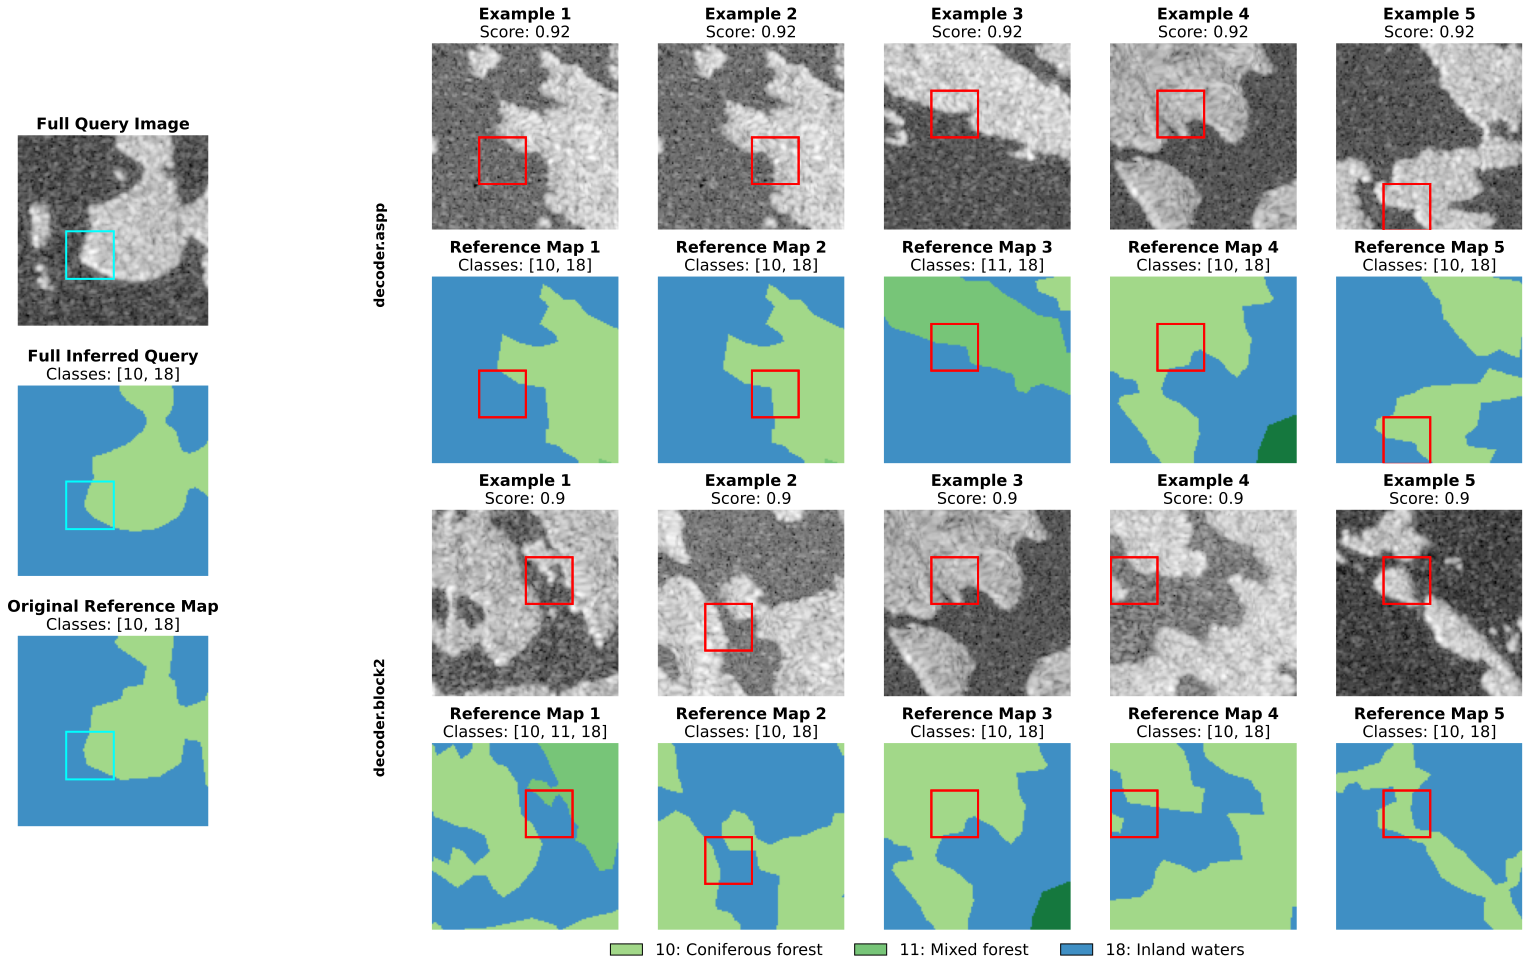

Figure saved as plots/deeplabv3p_examples_ref_1


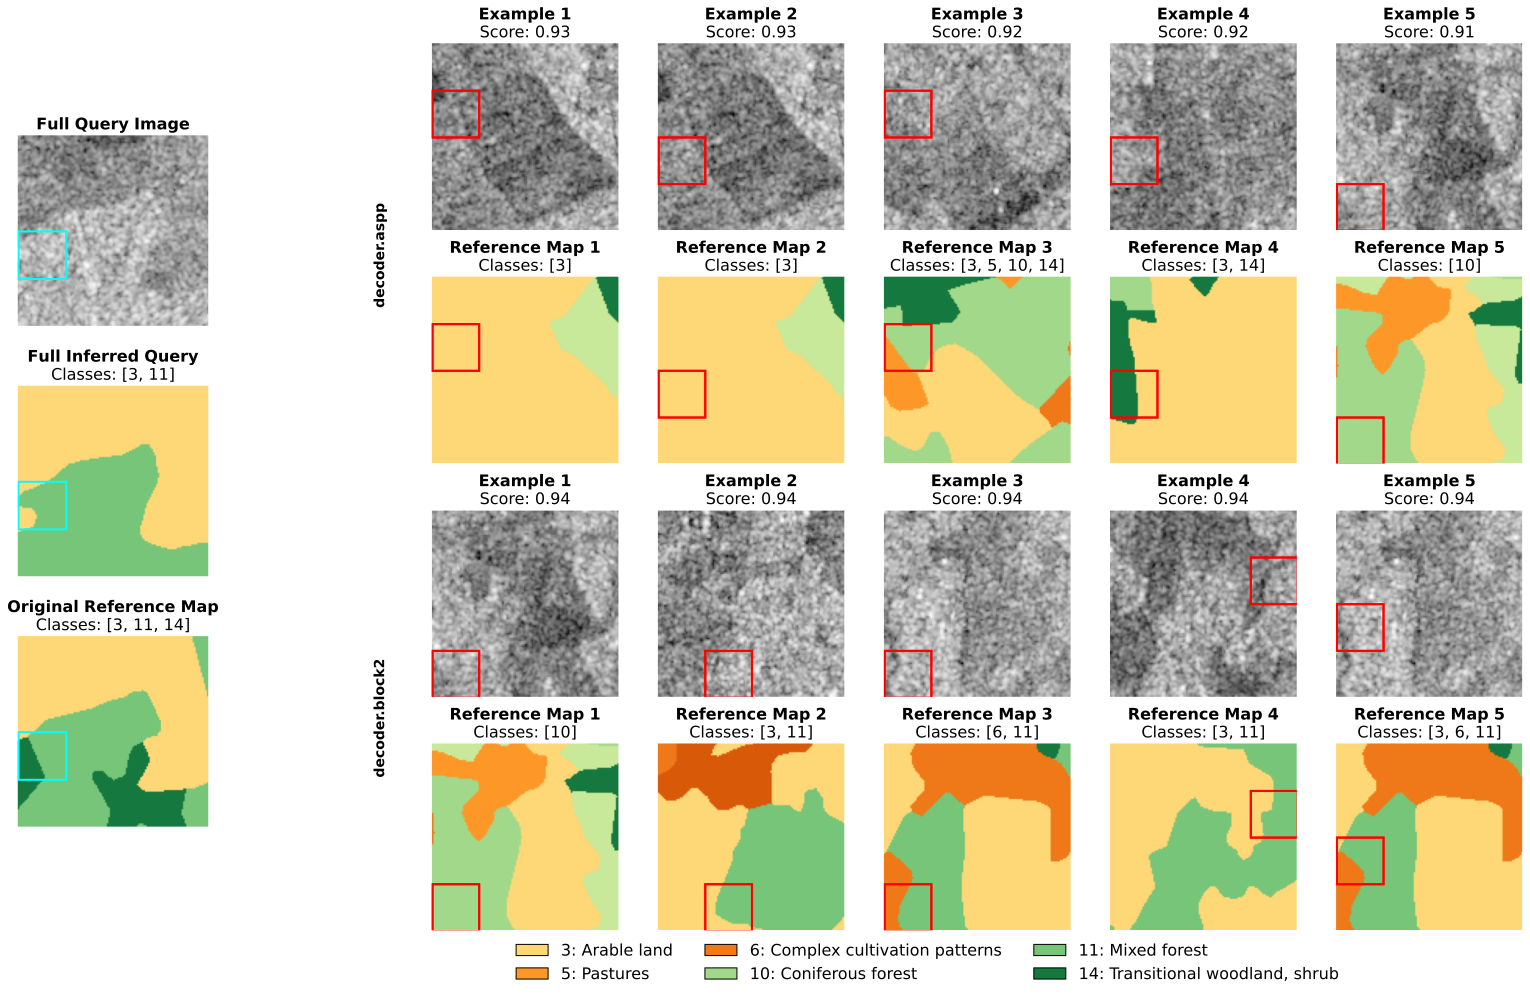

Figure saved as plots/deeplabv3p_examples_ref_2


In [12]:
refs = [
    #(layer_names[2:4], "S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48", [0, 0, 30, 30], "S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map",
    (layer_names[2:4],"S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_66_57", [30, 60, 60, 90], "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_66_57_reference_map"),
    (layer_names[2:4],"S1B_IW_GRDH_1SDV_20170929T045032_34UEG_48_26", [0, 60.0, 30.0, 90.0], "S2B_MSIL2A_20170930T095019_N9999_R079_T34UEG_48_26_reference_map"),
]

name = "deeplabv3p_examples"


for idx, (layers, img_ref, region, mask_ref) in enumerate(refs):
    plot_query_examples(
        image_ref=img_ref,
        mask_ref=mask_ref,
        region=region,
        layers_to_plot=layers,
        model=model,
        dataset_lmdb_path=dataset_lmdb_path,
        parquet_path=parquet_path,
        index_to_label=index_to_label,
        label_to_color=label_to_color,
        df_top_matches=df_top_matches,
        top_x=5,
        target=target,  # Change between "infer" and "reference",
        filename= f"plots/{name}_{target}_{idx+1}",
        # format="svg"
    )

# Comparison of 50 refences to U-Net results   


LAYER PAIR               | DL in U-Net  | U-Net in DL 
(DeepLab / U-Net)        | (Mean Overlap) | (Mean Overlap)
--------------------------------------------------
encoder.layer3           |         3.42 |         3.34
encoder.layer4           |         1.54 |         1.64
aspp / up1               |         1.08 |         1.12
block2 / up2             |         1.16 |         1.10



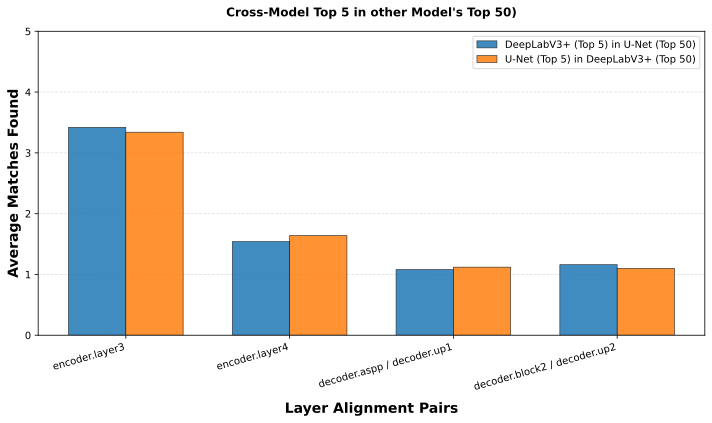

In [13]:
# load data
df_deeplab = pd.read_csv("top_matches_deeplabv3p.csv")
df_unet = pd.read_csv("top_matches_skipp_conn.csv")

df_deeplab["parsed_region"] = df_deeplab["original_region"].apply(ast.literal_eval)
df_unet["parsed_region"] = df_unet["original_region"].apply(ast.literal_eval)

unique_queries = df_deeplab[["image_id", "parsed_region"]].drop_duplicates().values
total_queries = len(unique_queries)

layer_alignment_pairs = [
    ("encoder.layer3", "encoder.layer3"),
    ("encoder.layer4", "encoder.layer4"),
    ("decoder.aspp", "decoder.up1"),
    ("decoder.block2", "decoder.up2"),
]

comparison_directions = ["DL in U-Net", "U-Net in DL"]

# setup plot
plt.figure(figsize=(10, 6))
x_indexes = np.arange(len(layer_alignment_pairs))
bar_width = 0.35

results = {dir_name: {"mean": []} for dir_name in comparison_directions}

for dl_layer, unet_layer in layer_alignment_pairs:
    overlap_dir1 = np.zeros(total_queries)
    overlap_dir2 = np.zeros(total_queries)
    valid_query_count = 0
    
    for query_idx, (image_id, region) in enumerate(unique_queries):
        sub_df_dl = df_deeplab[(df_deeplab["image_id"] == image_id) & (df_deeplab["parsed_region"] == region)]
        sub_df_un = df_unet[(df_unet["image_id"] == image_id) & (df_unet["parsed_region"] == region)]
        
        if len(sub_df_dl) == 0 or len(sub_df_un) == 0:
            continue
            
        # full match sequences
        dl_matches = [m[1] for m in ast.literal_eval(sub_df_dl[sub_df_dl["layer"] == dl_layer]["top_n"].values[0])]
        un_matches = [m[1] for m in ast.literal_eval(sub_df_un[sub_df_un["layer"] == unet_layer]["top_n"].values[0])]
        
        # cross-over intersections (Top 5 inside Top 50)
        overlap_dir1[query_idx] = len(set(dl_matches[:5]) & set(un_matches[:50]))
        overlap_dir2[query_idx] = len(set(un_matches[:5]) & set(dl_matches[:50]))
        
        valid_query_count += 1

    results["DL in U-Net"]["mean"].append(overlap_dir1[:valid_query_count].mean())
    results["U-Net in DL"]["mean"].append(overlap_dir2[:valid_query_count].mean())

# table
print("\n" + "="*50)
print(f"{'LAYER PAIR':<24} | {'DL in U-Net':<12} | {'U-Net in DL':<12}")
print(f"{'(DeepLab / U-Net)':<24} | {'(Mean Overlap)':<12} | {'(Mean Overlap)':<12}")
print("-"*50)

for i, (dl_layer, unet_layer) in enumerate(layer_alignment_pairs):
    layer_label = dl_layer if dl_layer == unet_layer else f"{dl_layer.split('.')[-1]} / {unet_layer.split('.')[-1]}"
    m1 = results["DL in U-Net"]["mean"][i]
    m2 = results["U-Net in DL"]["mean"][i]
    print(f"{layer_label:<24} | {m1:>12.2f} | {m2:>12.2f}")
print("="*50 + "\n")

for idx, dir_name in enumerate(comparison_directions):
    means = results[dir_name]["mean"]
    horizontal_offset = (idx - 0.5) * bar_width
    
    plt.bar(
        x_indexes + horizontal_offset, 
        means, 
        width=bar_width, 
        label="DeepLabV3+ (Top 5) in U-Net (Top 50)" if dir_name == "DL in U-Net" else "U-Net (Top 5) in DeepLabV3+ (Top 50)",
        alpha=0.85,
        edgecolor="black",
        linewidth=0.6
    )

layer_labels = [f"{dl} / {un}" if dl != un else dl for dl, un in layer_alignment_pairs]
plt.xticks(x_indexes, layer_labels, rotation=16, ha="right")
plt.ylabel("Average Matches Found", fontsize=14, fontweight="bold")
plt.xlabel("Layer Alignment Pairs", fontsize=14, fontweight="bold", labelpad=10)
plt.title("Cross-Model Top 5 in other Model's Top 50)", fontsize=12, fontweight="bold", pad=15)

plt.ylim(0, 5)  
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("plots/u_net_vs_deeplab_overlap_top5.pdf")
plt.show()